In [ ]:
import pandas as pd ;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

data = pd.read_csv(r"C:\Users\jorrik\Downloads\AI_Workflow_Optimization_Dataset_2500_Rows_v1.csv")
df = pd.DataFrame(data)

In [8]:
df.head()

,Workflow_ID,Process_Name,Task_ID,Task_Type,Priority_Level,Department,Assigned_Employee_ID,Task_Start_Time,Task_End_Time,Estimated_Time_Minutes,Actual_Time_Minutes,Delay_Flag,Approval_Level,Employee_Workload,Cost_Per_Task
0,WF_1,Customer Complaint,TASK_1,Review,Low,Customer Service,EMP_128,2024-01-25 04:47:00,2024-01-25 08:33:00,208,226,1,Level 1,1,155.17
1,WF_2,HR Onboarding,TASK_2,Approval,Low,HR,EMP_35,2024-05-24 02:57:00,2024-05-24 06:19:00,194,202,1,Level 2,5,231.54
2,WF_3,Invoice Approval,TASK_3,Review,High,Finance,EMP_88,2024-03-22 03:34:00,2024-03-22 08:51:00,214,317,1,Level 1,8,280.95
3,WF_4,Customer Complaint,TASK_4,Review,Medium,Operations,EMP_133,2024-06-10 10:37:00,2024-06-10 13:36:00,176,179,1,Level 3,1,413.74
4,WF_5,Customer Complaint,TASK_5,Escalation,Medium,Finance,EMP_80,2024-07-02 11:38:00,2024-07-02 15:36:00,197,238,1,Level 3,3,152.30


Understanding Dataset
Time tracking → Estimated_Time_Minutes, Actual_Time_Minutes
Efficiency → delays, workload
Cost → Cost_Per_Task
Process → Process_Name, Department, Task_Type

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Workflow_ID             2500 non-null   object 
 1   Process_Name            2500 non-null   object 
 2   Task_ID                 2500 non-null   object 
 3   Task_Type               2500 non-null   object 
 4   Priority_Level          2500 non-null   object 
 5   Department              2500 non-null   object 
 6   Assigned_Employee_ID    2500 non-null   object 
 7   Task_Start_Time         2500 non-null   object 
 8   Task_End_Time           2500 non-null   object 
 9   Estimated_Time_Minutes  2500 non-null   int64  
 10  Actual_Time_Minutes     2500 non-null   int64  
 11  Delay_Flag              2500 non-null   int64  
 12  Approval_Level          2500 non-null   object 
 13  Employee_Workload       2500 non-null   int64  
 14  Cost_Per_Task           2500 non-null   

In [12]:
df.describe()

,Estimated_Time_Minutes,Actual_Time_Minutes,Delay_Flag,Employee_Workload,Cost_Per_Task
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,123.910000,180.864000,0.949200,5.520400,277.976708
std,66.200536,75.562089,0.219633,2.842115,130.761056
min,10.000000,7.000000,0.000000,1.000000,50.320000
25%,67.000000,123.000000,1.000000,3.000000,164.162500
50%,121.000000,180.000000,1.000000,6.000000,279.355000
75%,181.000000,238.250000,1.000000,8.000000,388.007500
max,240.000000,357.000000,1.000000,10.000000,499.940000


In [11]:
df.isnull().sum()

Workflow_ID               0
Process_Name              0
Task_ID                   0
Task_Type                 0
Priority_Level            0
Department                0
Assigned_Employee_ID      0
Task_Start_Time           0
Task_End_Time             0
Estimated_Time_Minutes    0
Actual_Time_Minutes       0
Delay_Flag                0
Approval_Level            0
Employee_Workload         0
Cost_Per_Task             0
dtype: int64

How long tasks actually take?

In [27]:
#avg task handling time
df["Actual_Time_Minutes"].mean()

np.float64(180.864)

In [65]:
#% of tasks delayed?
df["Delay%"] = (df["Delay_Flag"].sum() / len(df))*100 


In [64]:
#High Priority Delay Rate
df[df["Priority_Level"] == "High"]["Delay_Flag"].mean() * 100

np.float64(94.66019417475728)

In [66]:
#Efficiency
df["efficiency"] = df["Estimated_Time_Minutes"] / df["Actual_Time_Minutes"] 
df["efficiency"].mean()

np.float64(0.6693833030843224)

In [63]:
df["Overrun"] = df["Actual_Time_Minutes"] - df["Estimated_Time_Minutes"]
df["Overrun"]

0        18
1         8
2       103
3         3
4        41
       ... 
2495     37
2496     26
2497     97
2498     65
2499      7
Name: Overrun, Length: 2500, dtype: int64

In [67]:
#Approval Level Impact
df.groupby("Approval_Level")["Actual_Time_Minutes"].mean()

Approval_Level
Level 1    180.777240
Level 2    180.445798
Level 3    181.350528
Name: Actual_Time_Minutes, dtype: float64

In [37]:
#Total Cost
df["Cost_Per_Task"].sum()

np.float64(694941.77)

In [38]:
#average cost per task
df["Cost_Per_Task"].mean()

np.float64(277.97670800000003)

In [39]:
#workload distribution
df["Employee_Workload"].value_counts()

Employee_Workload
5     271
6     258
9     255
7     255
1     252
8     252
4     250
3     240
10    237
2     230
Name: count, dtype: int64

In [41]:
#department wise performance
df.groupby("Department")["Actual_Time_Minutes"].mean()

Department
Customer Service    179.538618
Finance             176.343254
HR                  181.695219
IT                  185.150905
Operations          181.621782
Name: Actual_Time_Minutes, dtype: float64

In [45]:
#delay by department
df.groupby("Department")["Delay_Flag"].mean()*100

Department
Customer Service    93.902439
Finance             95.238095
HR                  95.219124
IT                  95.372233
Operations          94.851485
Name: Delay_Flag, dtype: float64

In [47]:
#process efficiency
df.groupby("Process_Name")["efficiency"].mean() *100

Process_Name
Customer Complaint    68.210088
HR Onboarding         67.228185
IT Support Ticket     66.899763
Invoice Approval      65.993293
Purchase Order        66.334107
Name: efficiency, dtype: float64

In [50]:
#cost by process
df.groupby("Process_Name")["Cost_Per_Task"].sum()

Process_Name
Customer Complaint    137188.16
HR Onboarding         137843.72
IT Support Ticket     137606.43
Invoice Approval      136810.56
Purchase Order        145492.90
Name: Cost_Per_Task, dtype: float64

In [54]:
#average handling time of processes
df.groupby("Process_Name")["Actual_Time_Minutes"].mean()

Process_Name
Customer Complaint    185.688623
HR Onboarding         175.398039
IT Support Ticket     182.593496
Invoice Approval      180.437500
Purchase Order        180.330754
Name: Actual_Time_Minutes, dtype: float64

In [70]:
#employee performance
df.groupby("Assigned_Employee_ID")["efficiency"].mean()

Assigned_Employee_ID
EMP_1      0.626879
EMP_10     0.557564
EMP_100    0.615678
EMP_101    0.682975
EMP_102    0.687357
             ...   
EMP_95     0.743432
EMP_96     0.637987
EMP_97     0.662246
EMP_98     0.574481
EMP_99     0.712707
Name: efficiency, Length: 150, dtype: float64

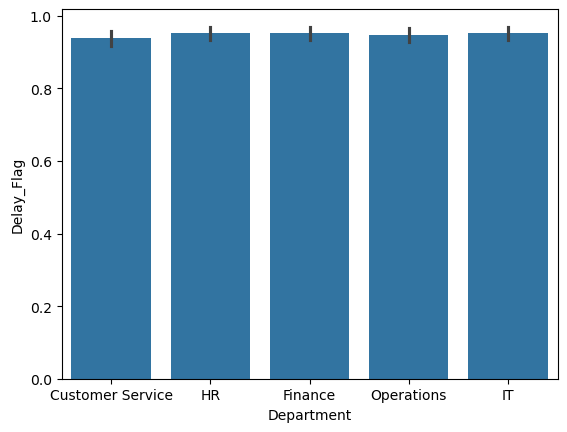

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Department", y="Delay_Flag", data=df)
plt.show()

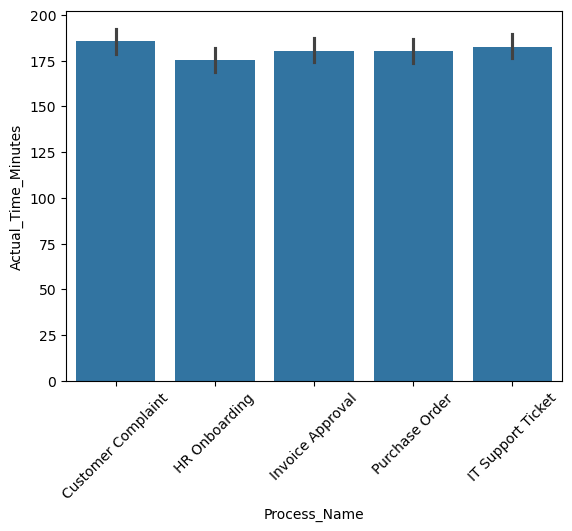

In [56]:
sns.barplot(x="Process_Name", y="Actual_Time_Minutes", data=df)
plt.xticks(rotation=45)
plt.show()

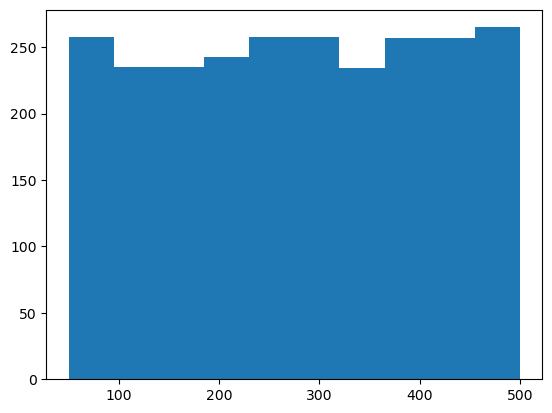

In [58]:
#cost distribution
plt.hist(df["Cost_Per_Task"])
plt.show()